In [ ]:
from pathlib import Path
import datetime as dt
import xarray as xr
import numpy as np
import pandas as pd
import dask
import cartopy.crs as ccrs
import cartopy.feature as cf
from matplotlib.cm import get_cmap
from matplotlib import pyplot as plt
import cmocean

In [ ]:
import socket

print(socket.gethostname())

chinook03.rcs.alaska.edu


In [ ]:
socket.gethostname().split(".")[-1]

'edu'

In [ ]:
resolution = 4         # 4 or 12 km
projdir = Path().resolve().parents[0]
if socket.gethostname().split(".")[-1] == "clstr":
    projdir = Path().resolve()

datadir = projdir / "extraction/20260607"
chunking = {
    4: ['auto', 'auto'],
    12: ['auto', 'auto']
}

In [ ]:
datadir.exists()

True

In [ ]:
projection = ccrs.Stereographic(
    central_longitude=-152.0, # central_latitude=64.0, 
    true_scale_latitude=64.0, central_latitude=90)

# Explore 95th percentile of wind speed at 10 m for 4 km grid

In [ ]:
quantile_select = 0.9

In [ ]:
winddatapth = datadir / f"seasonal_percentiles_90_95.nc"
windDS = xr.open_dataset(winddatapth, chunks='auto')
windDS

<xarray.Dataset> Size: 14MB
Dimensions:   (south_north: 450, west_east: 420, quantile: 2, season: 4)
Coordinates:
    XLONG     (south_north, west_east) float32 756kB dask.array<chunksize=(450, 420), meta=np.ndarray>
    XLAT      (south_north, west_east) float32 756kB dask.array<chunksize=(450, 420), meta=np.ndarray>
  * quantile  (quantile) float64 16B 0.9 0.95
  * season    (season) <U3 48B 'DJF' 'MAM' 'JJA' 'SON'
Dimensions without coordinates: south_north, west_east
Data variables:
    wspd10    (season, quantile, south_north, west_east) float64 12MB dask.array<chunksize=(4, 2, 450, 420), meta=np.ndarray>

In [ ]:
wind_byseason = windDS.wspd10.sel(quantile=quantile_select).drop_vars('quantile')
wind_byseason

<xarray.DataArray 'wspd10' (season: 4, south_north: 450, west_east: 420)> Size: 6MB
dask.array<getitem, shape=(4, 450, 420), dtype=float64, chunksize=(4, 450, 420), chunktype=numpy.ndarray>
Coordinates:
    XLONG    (south_north, west_east) float32 756kB dask.array<chunksize=(450, 420), meta=np.ndarray>
    XLAT     (south_north, west_east) float32 756kB dask.array<chunksize=(450, 420), meta=np.ndarray>
  * season   (season) <U3 48B 'DJF' 'MAM' 'JJA' 'SON'
Dimensions without coordinates: south_north, west_east

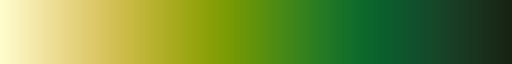

In [ ]:
cmocean.cm.speed

/tmp/ipykernel_3105374/4006389625.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  wind_byseason.sel(season=testssn).plot(cmap=get_cmap(cmocean.cm.speed), figsize=(10, 8))


Text(0.5, 1.0, 'DJF 90th percentile hourly windspeed (m/s)')

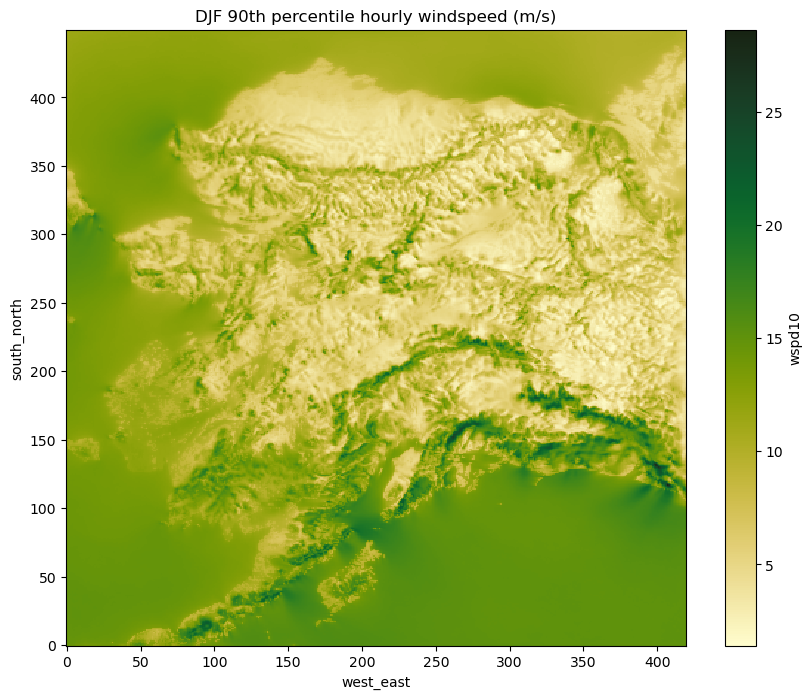

In [ ]:
levels = list(range(30))
testssn = 'DJF'
wind_byseason.sel(season=testssn).plot(cmap=get_cmap(cmocean.cm.speed), figsize=(10, 8))
plt.title(f"{testssn} {int(quantile_select*100)}th percentile hourly windspeed (m/s)")

/tmp/ipykernel_3105374/385882202.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  wind_byseason.sel(season=testssn).plot(levels=levels, cmap=get_cmap(cmocean.cm.speed), figsize=(10, 8))


Text(0.5, 1.0, 'DJF 90th percentile hourly windspeed (m/s)')

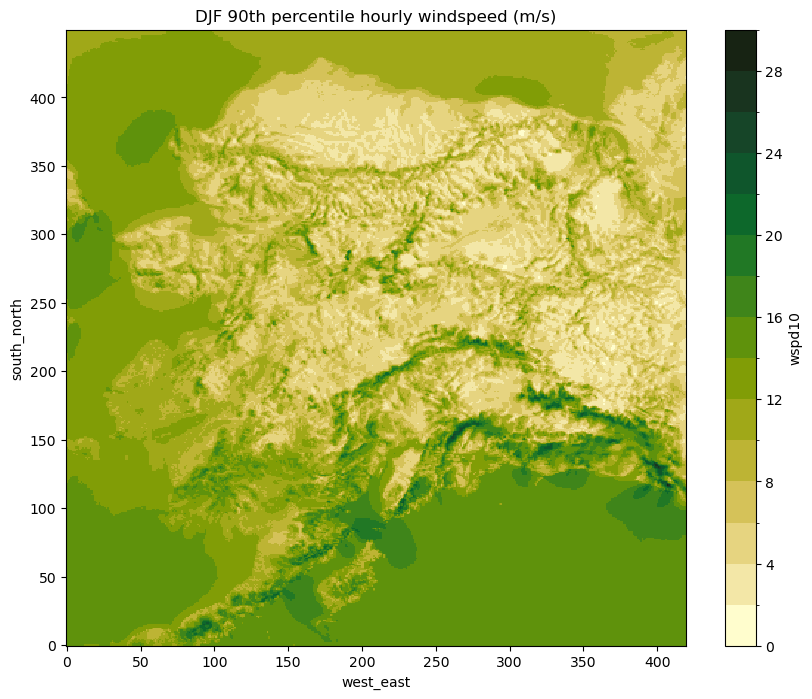

In [ ]:
levels = list(range(0, 31, 2))
testssn = 'DJF'
wind_byseason.sel(season=testssn).plot(levels=levels, cmap=get_cmap(cmocean.cm.speed), figsize=(10, 8))
plt.title(f"{testssn} {int(quantile_select*100)}th percentile hourly windspeed (m/s)")

/tmp/ipykernel_3105374/3535308850.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap=get_cmap(cmocean.cm.amp),
/import/SNAP/cwaigl/dyndowntools/.pixi/envs/default/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


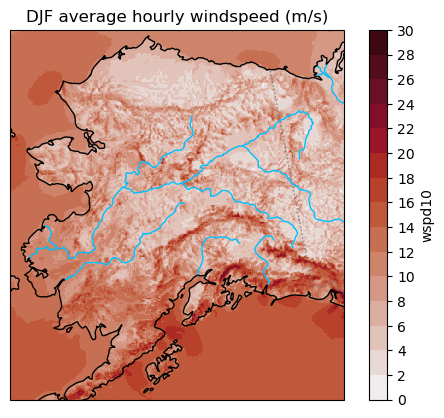

In [ ]:

testssn = 'DJF'
ax = plt.axes(projection=projection)
wind_byseason.sel(season=testssn).plot(
    levels=levels, cbar_kwargs={'ticks': levels},
    transform=ccrs.PlateCarree(),
    ax=ax,
    cmap=get_cmap(cmocean.cm.amp),
    x="XLONG", y="XLAT",
)
ax.coastlines()
ax.add_feature(cf.BORDERS, linestyle=':', color='grey')
ax.add_feature(cf.RIVERS, color='deepskyblue')
plt.title(f"{testssn} average hourly windspeed (m/s)")
ax.set_extent([-164.35, -140.3, 55.5, 71.3])
# ax.set_extent([-180, -130, 48, 75])

/tmp/ipykernel_3105374/2745120327.py:8: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap=get_cmap(cmocean.cm.amp),


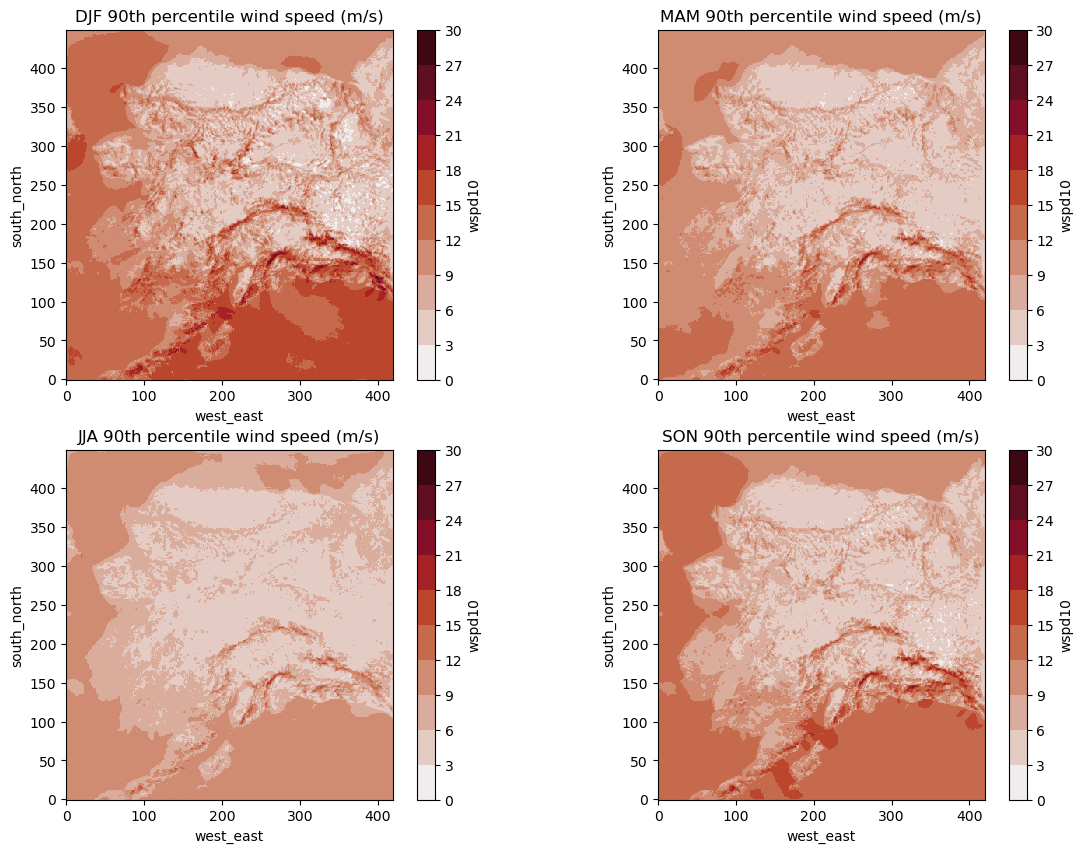

In [ ]:
levels = list(range(0,31,3))
seasons = ["DJF", "MAM", "JJA", "SON"]

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(14, 10))
for ssn, ax in zip(seasons, axes.flatten()):
    wind_byseason.sel(season=ssn).plot(
        levels=levels, cbar_kwargs={'ticks': levels},
        cmap=get_cmap(cmocean.cm.amp),
        ax=ax)
    ax.axes.set_aspect('equal')
    ax.set_title(f"{ssn} {int(quantile_select*100)}th percentile wind speed (m/s)")

/tmp/ipykernel_3105374/383524087.py:8: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap=get_cmap(cmocean.cm.speed),


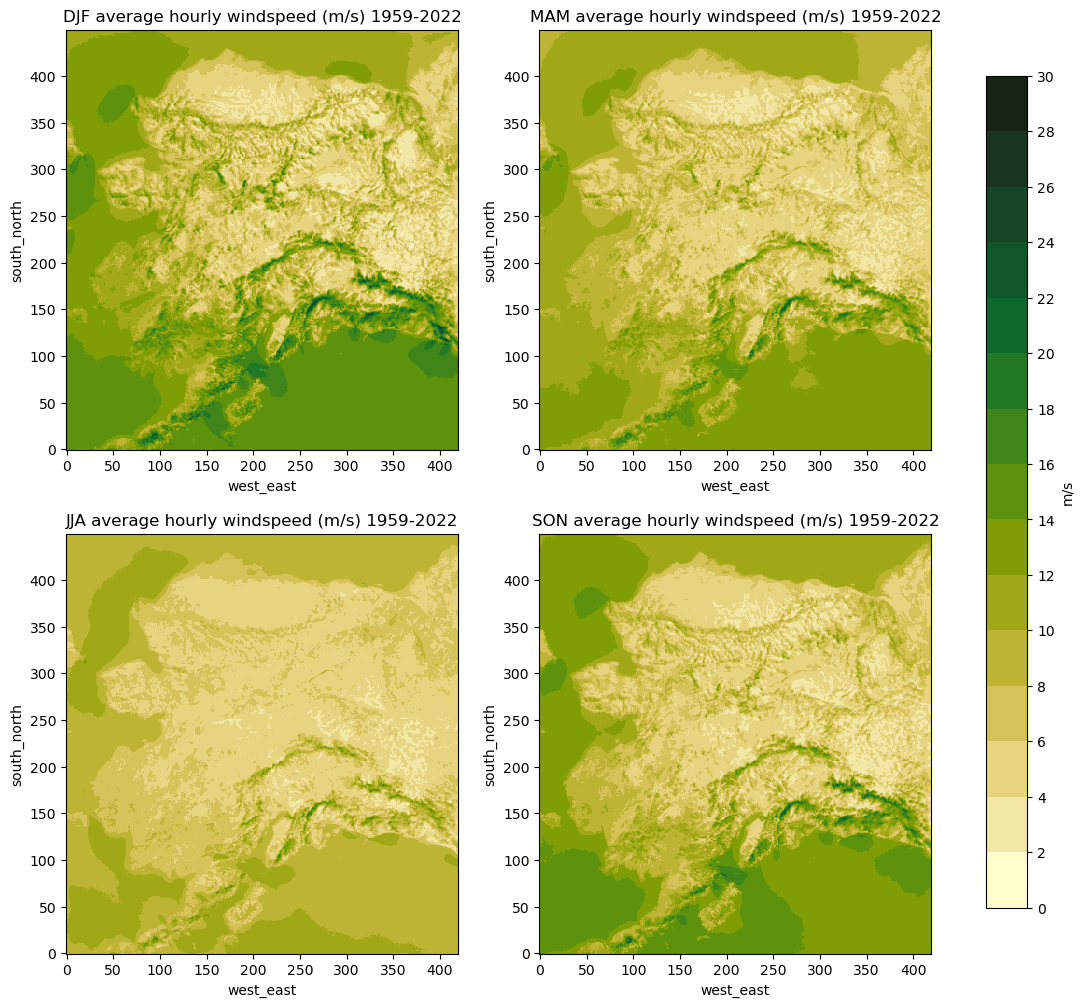

In [ ]:
levels = list(range(0,31,2))
seasons = ["DJF", "MAM", "JJA", "SON"]

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(14, 12))
for ssn, ax in zip(seasons, axes.flatten()):
    im = wind_byseason.sel(season=ssn).plot(
        levels=levels,
        cmap=get_cmap(cmocean.cm.speed),
        ax=ax, add_colorbar=False)
    ax.axes.set_aspect('equal')
    ax.set_title(f"{ssn} average hourly windspeed (m/s) 1959-2022")
cbar = fig.colorbar(im, ax=axes.ravel().tolist(), ticks=levels, shrink=0.9)
cbar.set_label('m/s')

In [ ]:
levels = list(range(0,28,2))

seasons = ["DJF", "MAM", "JJA", "SON"]
projection = projection
# extent = [-164.35, -140.3, 55.5, 71.3]

extent = [-166, -139, 55, 72]

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(10, 10.5), 
                         subplot_kw={'projection': projection},
                         constrained_layout=True)
for ssn, ax in zip(seasons, axes.flatten()):
    im = wind_byseason.sel(season=ssn).plot(
        levels=levels,
        transform=ccrs.PlateCarree(),
        ax=ax,
        cmap='cubehelix',
        x="XLONG", y="XLAT",
        add_colorbar=False)
    ax.set_extent(extent)
    ax.coastlines(linewidth=0.5)
    ax.add_feature(cf.BORDERS, linestyle=':', color='darkgrey')
    # ax.add_feature(cf.RIVERS, color='deepskyblue')
    ax.set_title(f"Season: {ssn}")
    ax.axis('off')
# fig.tight_layout()
cbar = fig.colorbar(im, ax=axes.ravel().tolist(), ticks=levels, 
                    shrink=0.8)
cbar.set_label('m/s')
fig.suptitle(f"{int(quantile_select*100)}th percentile hourly windspeed (m/s) 1959-2022")
# fig.subplots_adjust(wspace=0.2, hspace=0.2)


/import/SNAP/cwaigl/dyndowntools/.pixi/envs/default/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/import/SNAP/cwaigl/dyndowntools/.pixi/envs/default/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/import/SNAP/cwaigl/dyndowntools/.pixi/envs/default/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/import/SNAP/cwaigl/dyndowntools/.pixi/envs/default/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will 

Text(0.5, 0.98, '90th percentile hourly windspeed (m/s) 1959-2022')

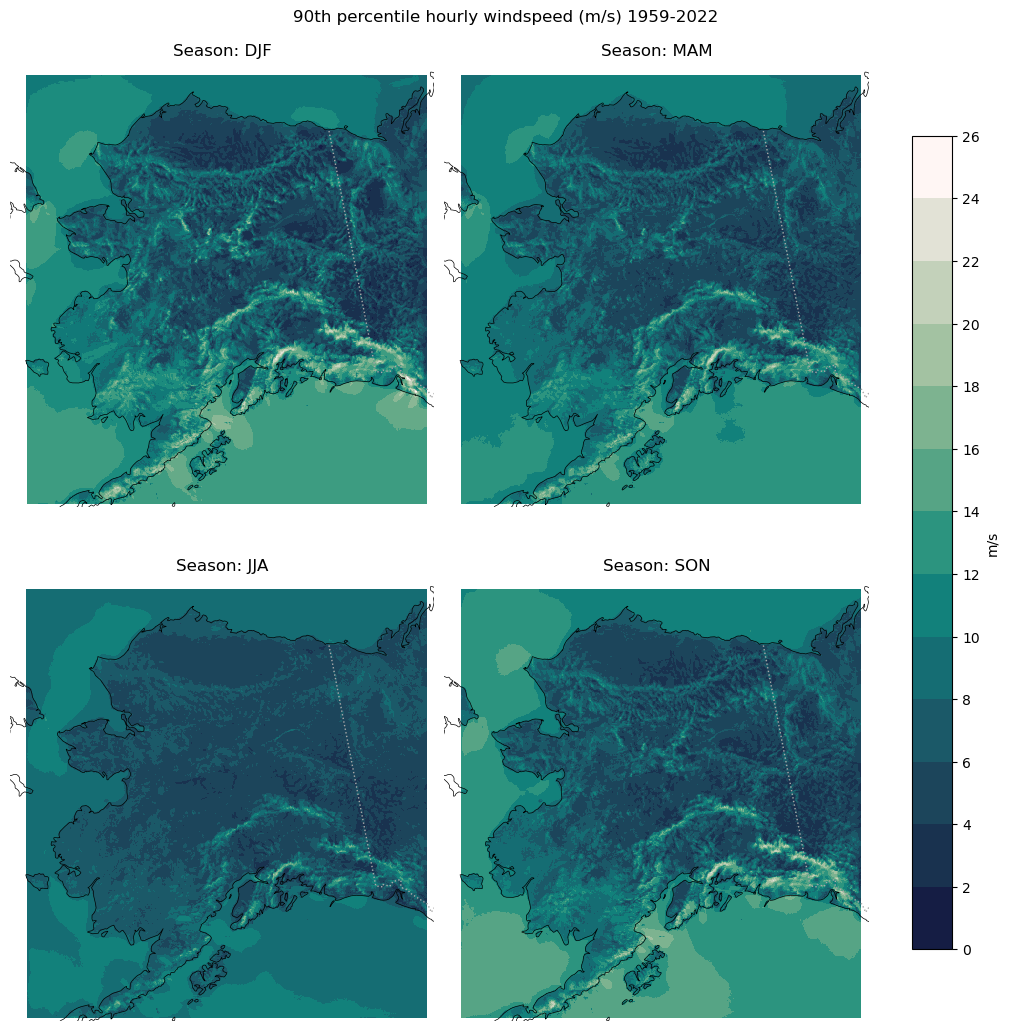

In [ ]:
levels = list(range(0,28,2))

seasons = ["DJF", "MAM", "JJA", "SON"]
projection = projection
# extent = [-164.35, -140.3, 55.5, 71.3]

extent = [-166, -139, 55, 72]

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(10, 10.5), 
                         subplot_kw={'projection': projection},
                         constrained_layout=True)
for ssn, ax in zip(seasons, axes.flatten()):
    im = wind_byseason.sel(season=ssn).plot(
        levels=levels,
        transform=ccrs.PlateCarree(),
        ax=ax,
        cmap=cmocean.cm.tempo_r,
        x="XLONG", y="XLAT",
        add_colorbar=False)
    ax.set_extent(extent)
    ax.coastlines(linewidth=0.5)
    ax.add_feature(cf.BORDERS, linestyle=':', color='darkgrey')
    # ax.add_feature(cf.RIVERS, color='deepskyblue')
    ax.set_title(f"Season: {ssn}")
    ax.axis('off')
# fig.tight_layout()
cbar = fig.colorbar(im, ax=axes.ravel().tolist(), ticks=levels, 
                    shrink=0.8)
cbar.set_label('m/s')
fig.suptitle(f"{int(quantile_select*100)}th percentile hourly windspeed (m/s) 1959-2022")
# fig.subplots_adjust(wspace=0.2, hspace=0.2)


/tmp/ipykernel_3105374/575209736.py:14: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap=get_cmap(cmocean.cm.tempo_r),
/import/SNAP/cwaigl/dyndowntools/.pixi/envs/default/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/tmp/ipykernel_3105374/575209736.py:14: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap=get_cmap(cmocean.cm.tempo_r),
/import/SNAP/cwaigl/dyndowntools/.pixi/envs/default/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will 

Text(0.5, 0.98, '90th percentile hourly windspeed (m/s) 1959-2022')

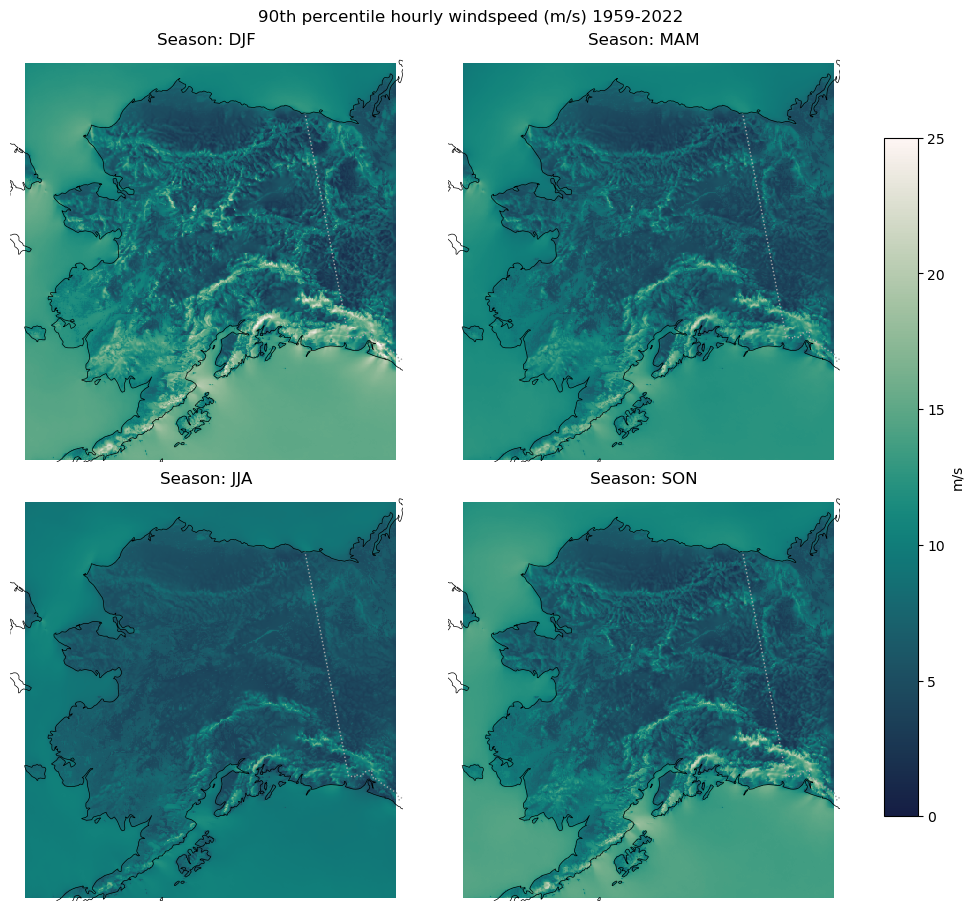

In [ ]:
seasons = ["DJF", "MAM", "JJA", "SON"]
projection = projection
# extent = [-164.35, -140.3, 55.5, 71.3]

extent = [-166, -139, 55, 72]

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(10, 9), 
                         subplot_kw={'projection': projection},
                         constrained_layout=True)
for ssn, ax in zip(seasons, axes.flatten()):
    im = wind_byseason.sel(season=ssn).plot(
        transform=ccrs.PlateCarree(),
        ax=ax,
        cmap=get_cmap(cmocean.cm.tempo_r),
        robust=True,
        vmin=0, vmax=25,
        x="XLONG", y="XLAT",
        add_colorbar=False)
    ax.set_extent(extent)
    ax.coastlines(linewidth=0.5)
    ax.add_feature(cf.BORDERS, linestyle=':', color='darkgrey')
    # ax.add_feature(cf.RIVERS, color='deepskyblue')
    ax.set_title(f"Season: {ssn}")
    ax.axis('off')
# fig.tight_layout()
cbar = fig.colorbar(im, ax=axes.ravel().tolist(), #ticks=levels, 
                    shrink=0.8)
cbar.set_label('m/s')
fig.suptitle(f"{int(quantile_select*100)}th percentile hourly windspeed (m/s) 1959-2022")

/tmp/ipykernel_3105374/1488691246.py:14: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap=get_cmap('cubehelix'),
/import/SNAP/cwaigl/dyndowntools/.pixi/envs/default/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/tmp/ipykernel_3105374/1488691246.py:14: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap=get_cmap('cubehelix'),
/import/SNAP/cwaigl/dyndowntools/.pixi/envs/default/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effe

Text(0.5, 0.98, '90th percentile hourly windspeed (m/s) 1959-2022')

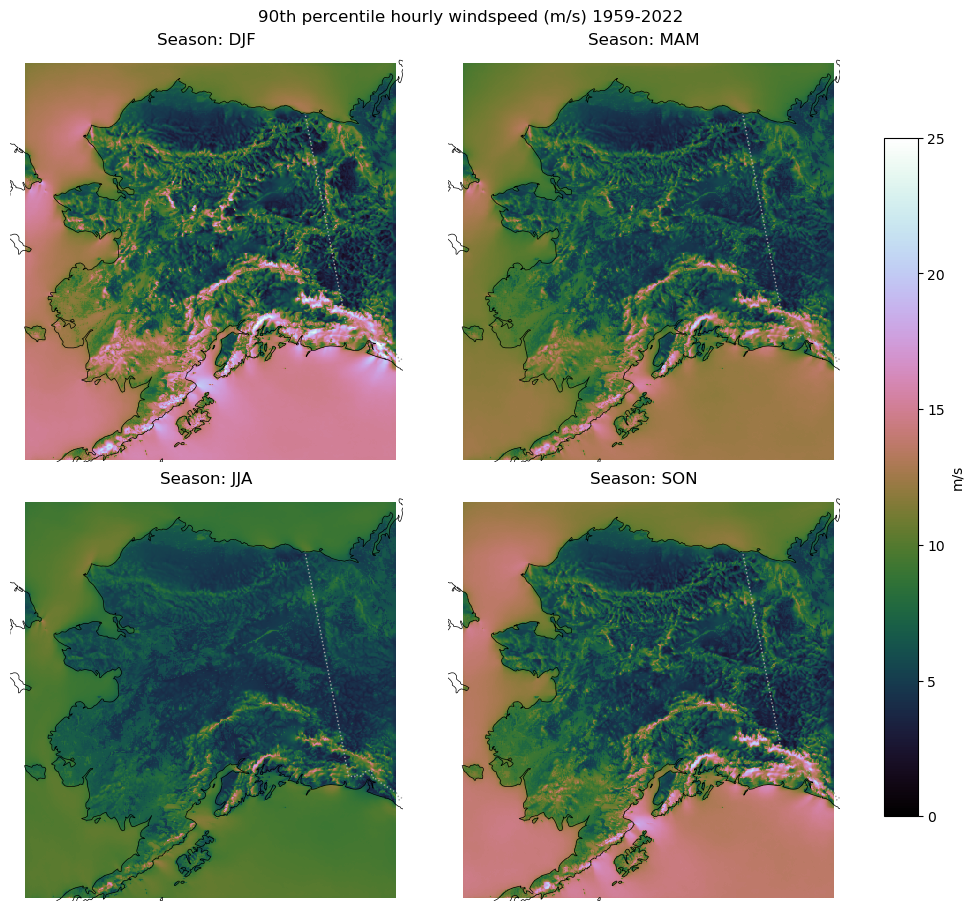

In [ ]:
seasons = ["DJF", "MAM", "JJA", "SON"]
projection = projection
# extent = [-164.35, -140.3, 55.5, 71.3]

extent = [-166, -139, 55, 72]

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(10, 9), 
                         subplot_kw={'projection': projection},
                         constrained_layout=True)
for ssn, ax in zip(seasons, axes.flatten()):
    im = wind_byseason.sel(season=ssn).plot(
        transform=ccrs.PlateCarree(),
        ax=ax,
        cmap=get_cmap('cubehelix'),
        robust=True,
        vmin=0, vmax=25,
        x="XLONG", y="XLAT",
        add_colorbar=False)
    ax.set_extent(extent)
    ax.coastlines(linewidth=0.5)
    ax.add_feature(cf.BORDERS, linestyle=':', color='darkgrey')
    # ax.add_feature(cf.RIVERS, color='deepskyblue')
    ax.set_title(f"Season: {ssn}")
    ax.axis('off')
# fig.tight_layout()
cbar = fig.colorbar(im, ax=axes.ravel().tolist(), #ticks=levels, 
                    shrink=0.8)
cbar.set_label('m/s')
fig.suptitle(f"{int(quantile_select*100)}th percentile hourly windspeed (m/s) 1959-2022")